## Gradient Descent Implementation

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# data
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 1 + 2 * X + np.random.randn(100) * 0.3

In [3]:
# model
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = 0.0
        self.b = 0.0
        self.loss_history = []

    def predict(self, X):
        return self.w * X + self.b

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iter):
            y_pred = self.predict(X)
            dw = (-2/n) * np.sum((y - y_pred) * X)
            db = (-2/n) * np.sum(y - y_pred)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.loss_history.append(self.mse(y, y_pred))

    def fit_sgd(self, X, y):
        n = len(X)
        for _ in range(self.n_iter):
            i = np.random.randint(0, n)
            y_pred_i = self.w * X[i] + self.b
            dw = (-2) * (y[i] - y_pred_i) * X[i]
            db = (-2) * (y[i] - y_pred_i)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.loss_history.append(self.mse(y, self.predict(X)))

    def fit_minibatch(self, X, y, batch_size=32):
        n = len(X)
        for _ in range(self.n_iter):
            indices = np.random.choice(n, batch_size, replace=False)
            X_batch, y_batch = X[indices], y[indices]
            y_pred_batch = self.predict(X_batch)
            dw = (-2/batch_size) * np.sum((y_batch - y_pred_batch) * X_batch)
            db = (-2/batch_size) * np.sum(y_batch - y_pred_batch)
            self.w -= self.lr * dw
            self.b -= self.lr * db

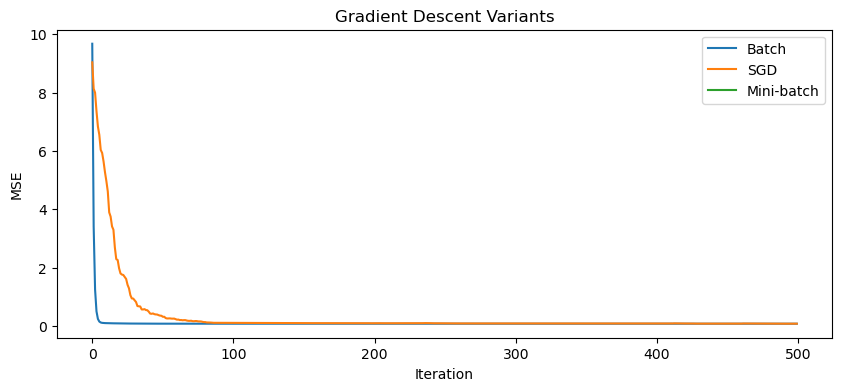

Batch      → w: 1.9310, b: 1.0645
SGD        → w: 1.8741, b: 1.1352
Mini-batch → w: 1.9349, b: 1.0673


In [4]:
# training
m1 = LinearRegressionFromScratch(learning_rate=0.1, n_iterations=500)
m1.fit(X, y)

m2 = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=500)
m2.fit_sgd(X, y)

m3 = LinearRegressionFromScratch(learning_rate=0.05, n_iterations=500)
m3.fit_minibatch(X, y)

plt.figure(figsize=(10, 4))
plt.plot(m1.loss_history, label='Batch')
plt.plot(m2.loss_history, label='SGD')
plt.plot(m3.loss_history, label='Mini-batch')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Variants')
plt.legend()
plt.show()

print(f"Batch      → w: {m1.w:.4f}, b: {m1.b:.4f}")
print(f"SGD        → w: {m2.w:.4f}, b: {m2.b:.4f}")
print(f"Mini-batch → w: {m3.w:.4f}, b: {m3.b:.4f}")